# Forecast Visualisations

Curated set of five figures, combining verified code from earlier notebooks this session
plus one new variant:

1. **Bias graph** -- reused verbatim from `forecast_characteristics.ipynb` Section 10d
   (3 panels: baseline as a shared reference line overlaid on control/single/dual).
2. **Reliability diagram, validation set** -- 4 panels (baseline gets its own panel here),
   reused from `reliability_diagram_train.ipynb`.
3. **Reliability diagram, test set** -- same construction, reused from
   `forecast_diagnostics.ipynb` Section 2.
4. **Monthly bias per forecaster** -- reused from `forecaster_tables.ipynb`'s 4-panel
   horizontal bar chart.
5. **Monthly spread per forecaster** -- new: the same upper/lower quantile-spread
   butterfly bar chart as `forecast_diagnostics.ipynb` Section 1, with the x-axis changed
   from hour-of-day to calendar month.

Only the reliability diagrams (validation + test) and the monthly spread chart need fresh
forecast passes; the test-year quantile collection is built once and reused by both the
test-set reliability diagram and the monthly spread chart. Monthly bias needs no forecast
passes at all -- it reads directly from the already-computed `raw_daily` results.

## Setup

In [1]:
from __future__ import annotations
import sys
import re
import dataclasses
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pyprojroot import here

sys.path.insert(0, str(here() / "8_testing"))
sys.path.insert(0, str(here() / "7_model_training"))
from eval_raw import (
    load_test_windows, forecast_quantiles, fresh_baseline_model, dfl_model_from,
    FORECASTING_DIR, DFL_TRAIN_DIR, COPULA_DIR, QUANTILE_LEVELS, FrozenCopulaSampler,
    RAW_DAILY_DIR,
)
from train_dfl_forecasts import load_data

SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]
DEFAULT_SEED = 20240801
FAMILY_BASE_ID = {
    "Baseline": None,
    "Control": "crps_only_retrained",
    "DFL single-price": "dfl_1stage_single-price",
    "DFL dual-price": "dfl_1stage_dual-price",
}
FAMILY_ORDER = list(FAMILY_BASE_ID)
FAMILY_COLORS = {"Baseline": "C0", "Control": "grey", "DFL single-price": "C6", "DFL dual-price": "C3"}
comparison_colors = {"Baseline": "C0", "Control": "grey", "DFL single-price": "C6", "DFL dual-price": "C3"}


def seed_variant(base_id, seed):
    return base_id if seed == DEFAULT_SEED else f"{base_id}_seed{seed}"


def seed_of(forecaster_id):
    m = re.search(r"_seed(\d+)", forecaster_id)
    return int(m.group(1)) if m else DEFAULT_SEED


print("loading windows...")
train_windows, val_windows = load_data()
test_windows = load_test_windows()

baseline_ckpt = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only=False, map_location="cpu")
sc = baseline_ckpt["scaler_stats"]
baseline_model = fresh_baseline_model(baseline_ckpt)


def load_dfl(forecaster_id):
    ck = torch.load(DFL_TRAIN_DIR / f"{forecaster_id}.pt", weights_only=False, map_location="cpu")
    return dfl_model_from(baseline_ckpt, ck)


idx10 = int(np.argmin(np.abs(QUANTILE_LEVELS - 0.10)))
idx50 = int(np.argmin(np.abs(QUANTILE_LEVELS - 0.50)))
idx90 = int(np.argmin(np.abs(QUANTILE_LEVELS - 0.90)))
print(f"n_val_days={len(val_windows.delivery_start)}  n_test_days={len(test_windows.delivery_start)}")

loading windows...


[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)


[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
n_val_days=181  n_test_days=366


## 1. Bias graph (test year, hourly)

Reused verbatim from `forecast_characteristics.ipynb` Section 10d.

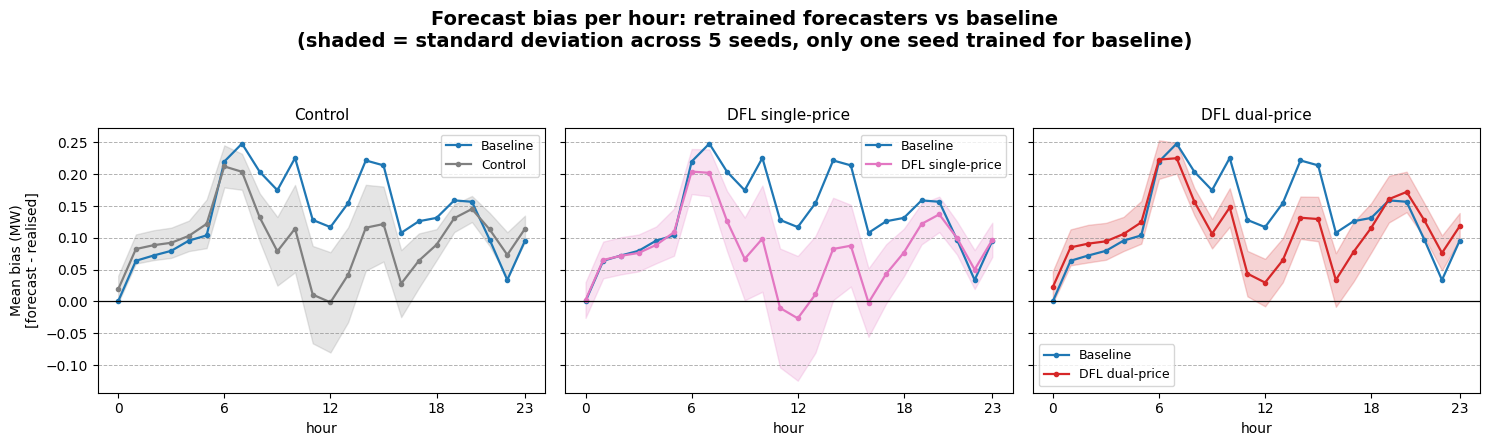

In [2]:
cop_bundle = pickle.load(open(COPULA_DIR / "frozen_copula.pkl", "rb"))
sampler = FrozenCopulaSampler(cop_bundle["Z_corr"], cop_bundle["quantile_levels"])
ALL_TEST_DAYS = range(len(test_windows.delivery_start))


def hourly_bias_own(model, windows, day_indices):
    errs = []
    for d in day_indices:
        q = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d])
        mean, _ = sampler.mean_and_errors(q)
        mean = mean.detach().cpu().numpy()
        realised = np.asarray(windows.y[d], float)
        errs.append(mean - realised)
    return np.mean(errs, axis=0)


def metric_across_seeds_bias(base_id):
    vals = np.array([hourly_bias_own(load_dfl(seed_variant(base_id, seed)), test_windows, ALL_TEST_DAYS) for seed in SEEDS])
    return vals.mean(axis=0), vals.std(axis=0)


def plot_metric_row(baseline_series, panels, colors, ylabel, fig_title):
    h = np.arange(24)
    fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4.5), sharey=True)
    
    for ax, (label, mean, std) in zip(axes, panels):
        ax.plot(h, baseline_series, "-o", color=colors["Baseline"], markersize=3, label="Baseline", linewidth=1.6)
        
        # 1. UPDATED: Simplified the legend label (removed "5 seed mean")
        ax.plot(h, mean, "-o", color=colors[label], markersize=3, label=label, linewidth=1.6)
        
        # 2. UPDATED: Removed the label from fill_between so it doesn't clutter the legend
        ax.fill_between(h, mean - std, mean + std, color=colors[label], alpha=0.2)
        
        ax.axhline(0, color="black", linewidth=0.9, zorder=2)
        ax.grid(axis="y", linestyle="--", linewidth=0.7, color="grey", alpha=0.6, zorder=0)
        ax.set_xlabel("hour")
        
        # 3. UPDATED: Set explicit x-axis ticks to represent logical times of day
        ax.set_xticks([0, 6, 12, 18, 23])
        
        ax.set_title(label, fontsize=11)
        ax.legend(fontsize=9, loc="best")
        
    axes[0].set_ylabel(ylabel)
    fig.suptitle(fig_title, fontsize=14, fontweight="bold")
    
    # 4. UPDATED: Added a rect parameter to prevent the two-line suptitle from overlapping subplots
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

# --- Data Generation / Function Call ---

bias_base = hourly_bias_own(baseline_model, test_windows, ALL_TEST_DAYS)
bias_crps_mean, bias_crps_std = metric_across_seeds_bias("crps_only_retrained")
bias_single_mean, bias_single_std = metric_across_seeds_bias("dfl_1stage_single-price")
bias_dual_mean, bias_dual_std = metric_across_seeds_bias("dfl_1stage_dual-price")

plot_metric_row(
    bias_base,
    [("Control", bias_crps_mean, bias_crps_std),
     ("DFL single-price", bias_single_mean, bias_single_std),
     ("DFL dual-price", bias_dual_mean, bias_dual_std)],
    comparison_colors, 
    # 5. UPDATED: Added a line break (\n) to separate the metric from the definition
    ylabel="Mean bias (MW)\n[forecast - realised]",
    # 6. UPDATED: Added line break and clarified the baseline's lack of standard deviation
    fig_title="Forecast bias per hour: retrained forecasters vs baseline\n(shaded = standard deviation across 5 seeds, only one seed trained for baseline)"
)

### Across-seed standard deviation of bias, by hour

Quantifies the shaded band width in the bias graph above directly: `bias_crps_std`,
`bias_single_std`, `bias_dual_std` (already computed there as the across-5-seed std of
each hour's bias) as a table, one row per hour. Baseline has no column -- it is a single
fixed checkpoint (n=1), which is exactly why it is plotted as a plain unshaded line
above.

In [3]:
hourly_bias_std_table = pd.DataFrame({
    "Control": bias_crps_std,
    "DFL single-price": bias_single_std,
    "DFL dual-price": bias_dual_std,
}, index=pd.RangeIndex(24, name="hour"))

display(hourly_bias_std_table.round(4))

,Control,DFL single-price,DFL dual-price
hour,,,
0,0.0213,0.0280,0.0250
1,0.0229,0.0289,0.0283
2,0.0235,0.0292,0.0296
3,0.0237,0.0290,0.0290
4,0.0240,0.0289,0.0268
5,0.0381,0.0369,0.0335
6,0.0330,0.0354,0.0303
7,0.0283,0.0368,0.0240
8,0.0377,0.0473,0.0213


## Shared quantile collection (validation + test year)

One forecast pass per (family, seed) over each period. The test-year cache is reused by
both Section 3 (reliability, test) and Section 5 (monthly spread).

In [4]:
def collect_quantiles(model, windows):
    n = len(windows.delivery_start)
    q_all = np.empty((n, 24, len(QUANTILE_LEVELS)))
    y_all = np.empty((n, 24))
    for d in range(n):
        q_all[d] = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d]).numpy()
        y_all[d] = np.asarray(windows.y[d], float)
    return q_all, y_all


def build_cache(windows):
    cache = {}
    for family in FAMILY_ORDER:
        base_id = FAMILY_BASE_ID[family]
        seeds = [DEFAULT_SEED] if family == "Baseline" else SEEDS
        for seed in seeds:
            model = baseline_model if family == "Baseline" else load_dfl(seed_variant(base_id, seed))
            cache[(family, seed)] = collect_quantiles(model, windows)
            print(f"  collected {family} seed={seed}", flush=True)
    return cache


print("collecting validation-set quantiles...")
cache_val = build_cache(val_windows)
print("collecting test-set quantiles...")
cache_test = build_cache(test_windows)

collecting validation-set quantiles...


  collected Baseline seed=20240801


  collected Control seed=20240801


  collected Control seed=20240802


  collected Control seed=20240803


...

  collected DFL dual-price seed=20240801


  collected DFL dual-price seed=20240802


  collected DFL dual-price seed=20240803


  collected DFL dual-price seed=20240804


  collected DFL dual-price seed=20240805


## 2 & 3. Reliability diagrams -- validation set and test set

Empirical coverage at each of the 19 native quantile levels, four panels (Baseline gets
its own panel here), N=5 seed mean +/- std shaded, 45-degree perfect-calibration
reference line -- two figures, one per period.

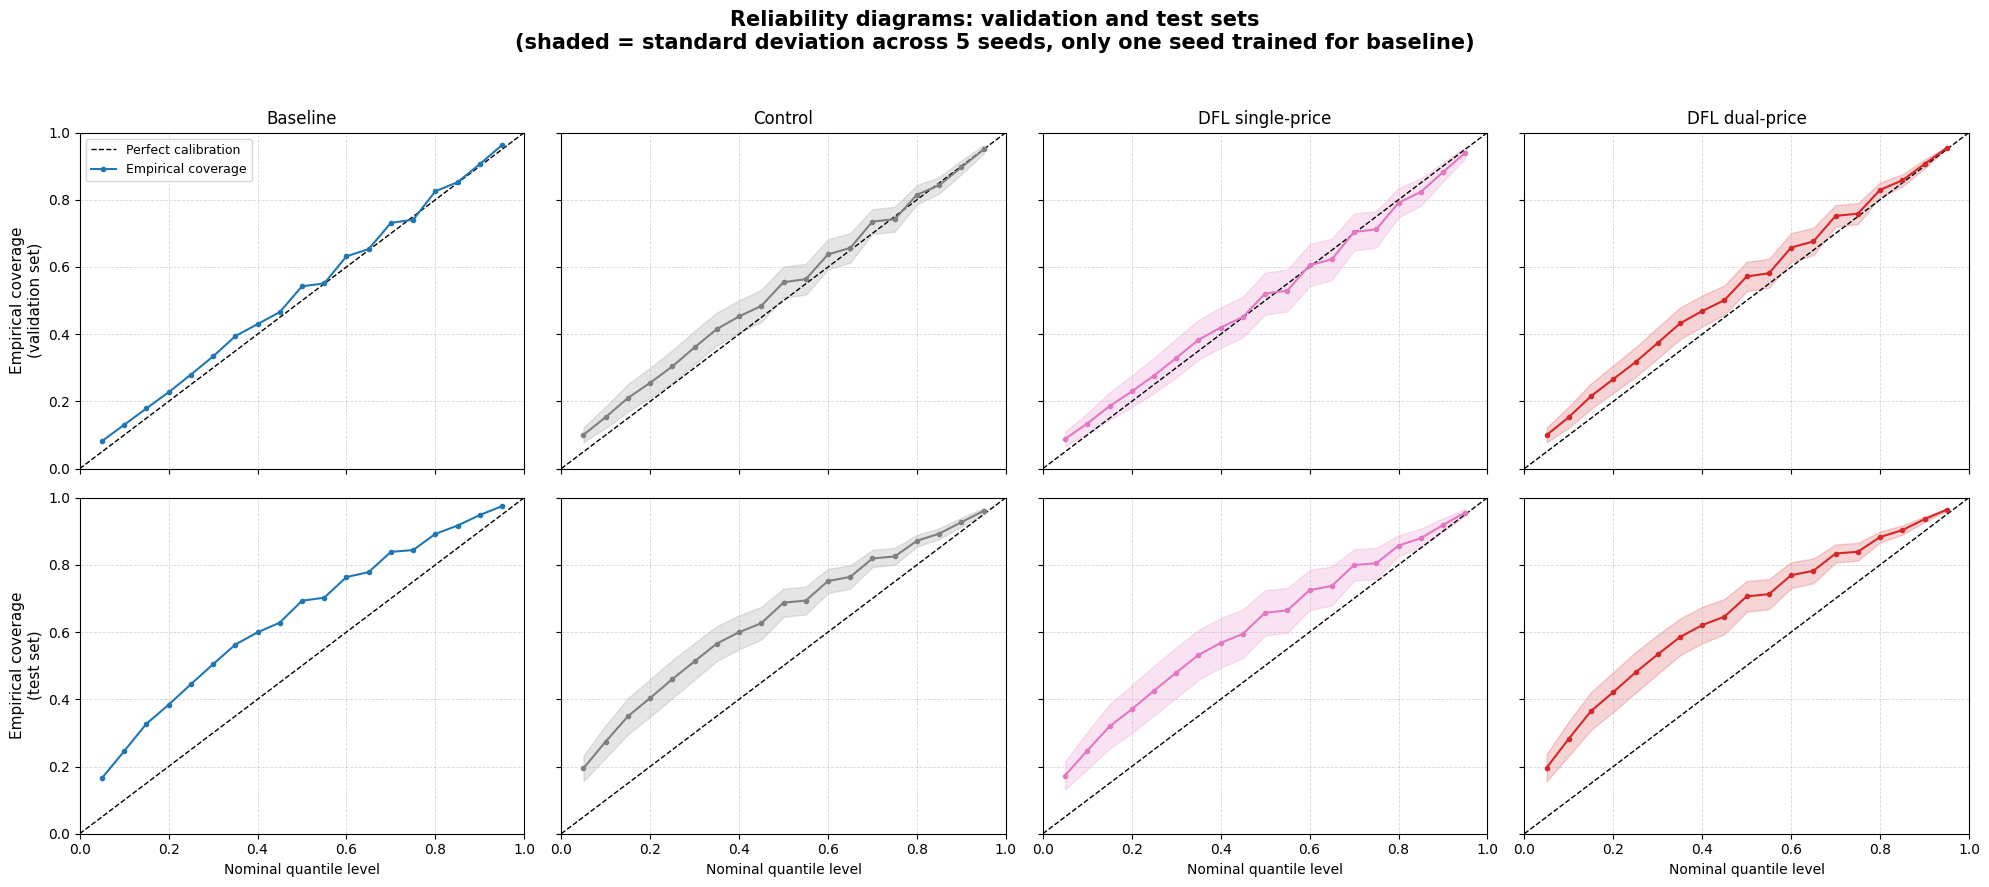

In [5]:
import matplotlib.pyplot as plt

def empirical_coverage(q_all, y_all):
    y_flat = y_all.reshape(-1)
    q_flat = q_all.reshape(-1, q_all.shape[-1])
    return (y_flat[:, None] <= q_flat).mean(axis=0)


def family_coverage_stats(family, cache):
    seeds = [DEFAULT_SEED] if family == "Baseline" else SEEDS
    covs = np.array([empirical_coverage(*cache[(family, seed)]) for seed in seeds])
    return covs.mean(axis=0), (covs.std(axis=0) if len(seeds) > 1 else None)


fig, axes = plt.subplots(
    2, 4, figsize=(20, 9), sharex=True, sharey=True
)

for row, (cache, period) in enumerate(
    [(cache_val, "Validation set"), (cache_test, "Test set")]
):
    for col, family in enumerate(FAMILY_ORDER):
        ax = axes[row, col]
        cov_mean, cov_std = family_coverage_stats(family, cache)

        ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
        ax.plot(
            QUANTILE_LEVELS,
            cov_mean,
            "-o",
            color=FAMILY_COLORS[family],
            markersize=3,
            label="Empirical coverage",
        )

        if cov_std is not None:
            ax.fill_between(
                QUANTILE_LEVELS,
                cov_mean - cov_std,
                cov_mean + cov_std,
                color=FAMILY_COLORS[family],
                alpha=0.2,
            )

        # 1. UPDATED: Only add titles to the top row
        if row == 0:
            ax.set_title(family, fontsize=12)
            
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(linestyle="--", linewidth=0.6, alpha=0.5)
        
        # 2. UPDATED: Only add the legend to the top-left Baseline plot
        if row == 0 and col == 0:
            ax.legend(fontsize=9, loc="upper left")

        if row == 1:
            ax.set_xlabel("Nominal quantile level")

# 3. UPDATED: Capitalized and formatted y-axis labels
axes[0, 0].set_ylabel("Empirical coverage\n(validation set)", fontsize=11)
axes[1, 0].set_ylabel("Empirical coverage\n(test set)", fontsize=11)

# 4. UPDATED: Added clarification for the baseline to the subtitle
fig.suptitle(
    "Reliability diagrams: validation and test sets\n"
    "(shaded = standard deviation across 5 seeds, only one seed trained for baseline)",
    fontsize=15, fontweight="bold",
)

# 5. UPDATED: Added a rect parameter to prevent the suptitle from clipping the top plots
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 4 & 5. Monthly bias and monthly spread, combined

Single figure, two rows x four columns (one column per forecaster), sharing one month
axis down the left (first month at the top, last at the bottom) -- row 1 is monthly bias
(reused from `forecaster_tables.ipynb`, no new forecast passes), row 2 is monthly spread
(reused from Section 5's original version, reusing the test-year quantile cache built
above). To share the month axis, the spread row is redrawn as horizontal bars to match
the bias row's orientation: upper spread (`q_0.9-q_0.5`) extends right, lower spread
(`q_0.5-q_0.1`) extends left (shown negative) from a centred zero line -- the same
butterfly convention as before, just rotated 90 degrees so both rows can share the y-axis.
Each row keeps its own x-axis scale (bias and spread are different quantities), shared
across that row's 4 columns.

Spread is non-negative by construction on both sides -- the left-extending "lower spread"
bars are drawn at negative x internally (so matplotlib draws them going left), but the
axis tick labels show `|x|`, not the signed value, since a negative-looking spread would
be misleading. The legend is a single shared one below the whole figure rather than
inline on one panel. Each retrained arm's panels (not baseline's own) also carry a thin
green tick per month/row showing where baseline sat for that same metric, so a retrained
arm can be read directly against baseline without cross-referencing the leftmost
column.

/tmp/ipykernel_736623/3527200194.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bias_df["month"] = bias_df["date"].dt.to_period("M").astype(str)


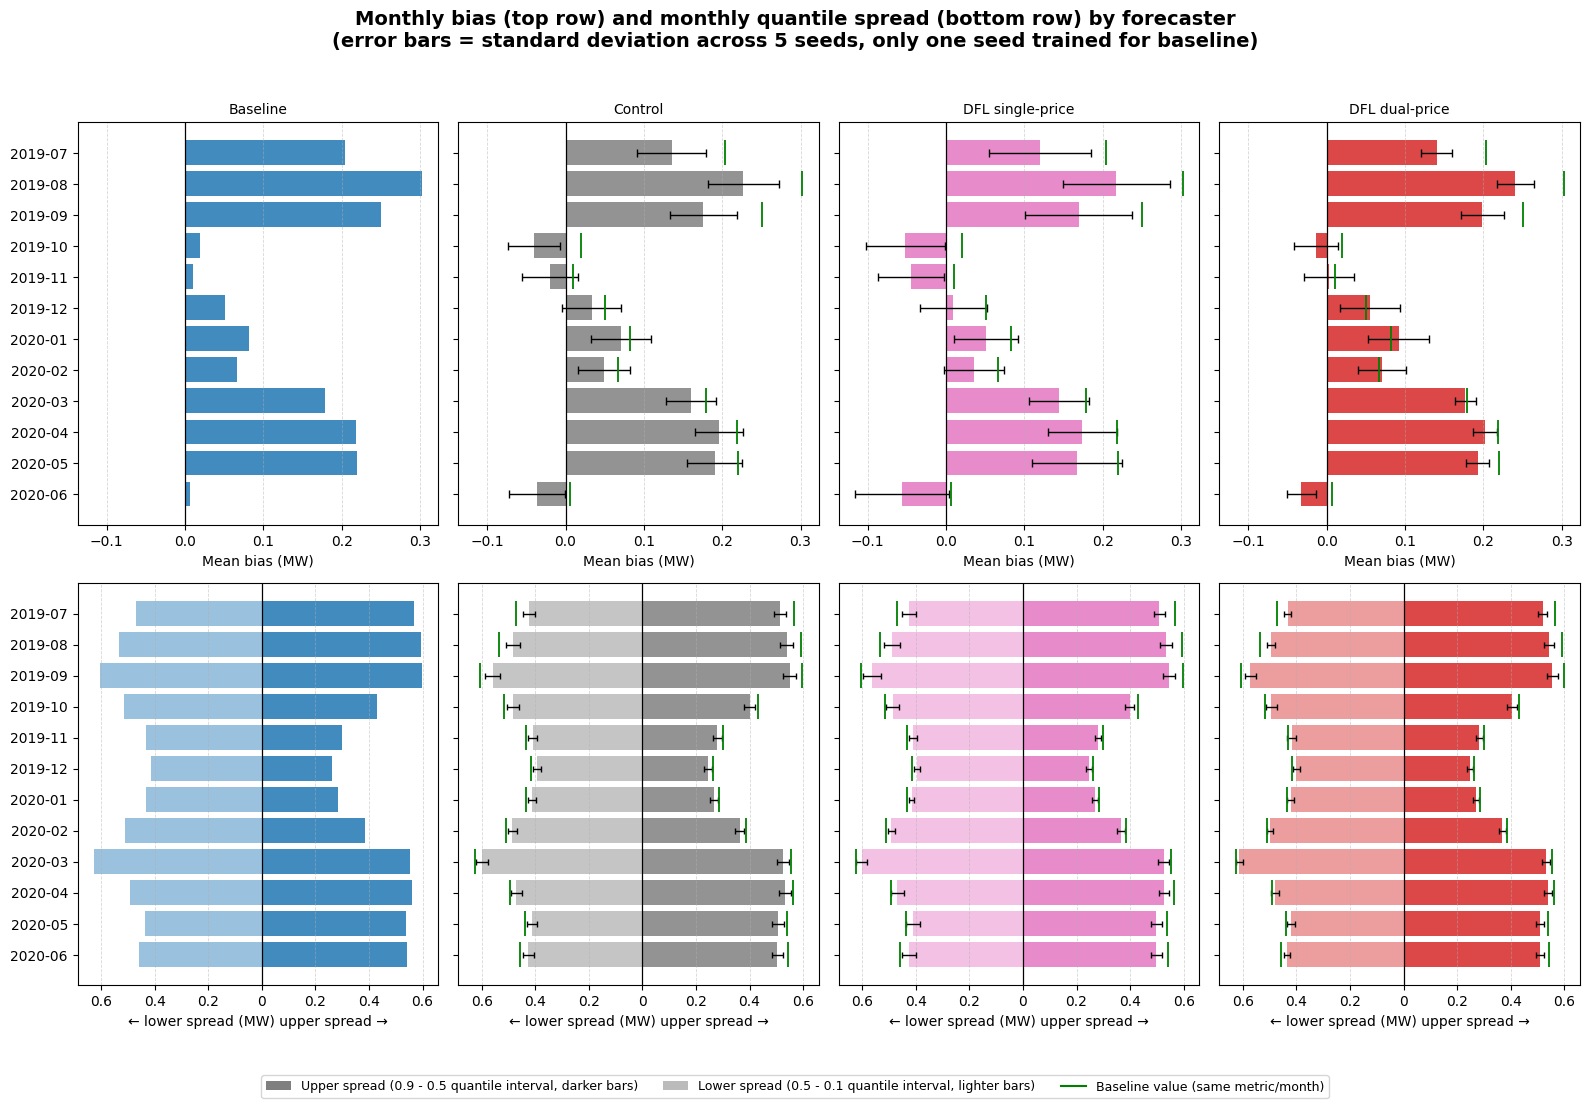

In [6]:
def family_of(forecaster_id):
    if forecaster_id == "baseline": return "Baseline"
    if forecaster_id.startswith("crps_only_retrained"): return "Control"
    if forecaster_id.startswith("dfl_1stage_single-price"): return "DFL single-price"
    if forecaster_id.startswith("dfl_1stage_dual-price"): return "DFL dual-price"
    return None


bias_df = pd.read_parquet(RAW_DAILY_DIR, columns=["forecaster_id", "price_mode", "date", "bias_MW"])
bias_df["date"] = pd.to_datetime(bias_df["date"])
bias_df = bias_df.drop_duplicates(subset=["forecaster_id", "date"])   # bias_MW is price-mode-independent
bias_df["month"] = bias_df["date"].dt.to_period("M").astype(str)
bias_df["family"] = bias_df["forecaster_id"].apply(family_of)
bias_df["seed"] = bias_df["forecaster_id"].apply(seed_of)
bias_df = bias_df[bias_df["family"].notna()]

months = sorted(bias_df["month"].unique())
y_pos = np.arange(len(months))
per_seed_monthly_bias = bias_df.groupby(["family", "seed", "month"])["bias_MW"].mean().reset_index()


def bias_stats(family):
    fam = per_seed_monthly_bias[per_seed_monthly_bias["family"] == family]
    stats = fam.groupby("month")["bias_MW"].agg(["mean", "std"]).reindex(months)
    return stats["mean"].to_numpy(), (stats["std"].to_numpy() if family != "Baseline" else None)


def monthly_spreads(q_all, delivery_start):
    """(n_months,) upper spread, (n_months,) lower spread -- averaged over every
    (day, hour) observation within each calendar month."""
    month_labels = pd.PeriodIndex(delivery_start, freq="M").astype(str)
    upper_per_day = q_all[:, :, idx90] - q_all[:, :, idx50]   # (n_days, 24)
    lower_per_day = q_all[:, :, idx50] - q_all[:, :, idx10]   # (n_days, 24)
    df = pd.DataFrame({
        "month": np.repeat(month_labels, 24),
        "upper": upper_per_day.reshape(-1),
        "lower": lower_per_day.reshape(-1),
    })
    g = df.groupby("month")[["upper", "lower"]].mean().reindex(months)
    return g["upper"].to_numpy(), g["lower"].to_numpy()


def family_spread_stats(family):
    seeds = [DEFAULT_SEED] if family == "Baseline" else SEEDS
    uppers, lowers = [], []
    for seed in seeds:
        u, l = monthly_spreads(cache_test[(family, seed)][0], test_windows.delivery_start)
        uppers.append(u); lowers.append(l)
    uppers, lowers = np.array(uppers), np.array(lowers)
    return (uppers.mean(axis=0), uppers.std(axis=0) if len(seeds) > 1 else None,
            lowers.mean(axis=0), lowers.std(axis=0) if len(seeds) > 1 else None)


from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

REF_TICK_HALF_HEIGHT = 0.4   # short vertical tick spanning each bar's own row, not a continuous line

baseline_bias_mean, _ = bias_stats("Baseline")
baseline_upper_mean, _, baseline_lower_mean, _ = family_spread_stats("Baseline")

fig, axes = plt.subplots(2, 4, figsize=(16, 11), sharex="row", sharey=True)

for col, family in enumerate(FAMILY_ORDER):
    ax = axes[0, col]
    mean, std = bias_stats(family)
    ax.barh(y_pos, mean, xerr=std, color=FAMILY_COLORS[family], alpha=0.85,
            capsize=3, error_kw=dict(elinewidth=1))
    if family != "Baseline":
        # thin green tick per month showing where baseline sat for the same metric
        ax.vlines(baseline_bias_mean, y_pos - REF_TICK_HALF_HEIGHT, y_pos + REF_TICK_HALF_HEIGHT,
                   color="green", linewidth=1.3, zorder=5)
    ax.axvline(0, color="black", linewidth=0.9, zorder=2)
    ax.set_title(family, fontsize=10)
    ax.set_xlabel("Mean bias (MW)")
    ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.5)

abs_fmt = FuncFormatter(lambda x, pos: f"{abs(x):g}")
for col, family in enumerate(FAMILY_ORDER):
    ax = axes[1, col]
    upper_mean, upper_std, lower_mean, lower_std = family_spread_stats(family)
    ax.barh(y_pos, upper_mean, xerr=upper_std, color=FAMILY_COLORS[family], alpha=0.85,
            capsize=2, error_kw=dict(elinewidth=1))
    ax.barh(y_pos, -lower_mean, xerr=lower_std, color=FAMILY_COLORS[family], alpha=0.45,
            capsize=2, error_kw=dict(elinewidth=1))
    if family != "Baseline":
        ax.vlines(baseline_upper_mean, y_pos - REF_TICK_HALF_HEIGHT, y_pos + REF_TICK_HALF_HEIGHT,
                   color="green", linewidth=1.3, zorder=5)
        ax.vlines(-baseline_lower_mean, y_pos - REF_TICK_HALF_HEIGHT, y_pos + REF_TICK_HALF_HEIGHT,
                   color="green", linewidth=1.3, zorder=5)
    ax.axvline(0, color="black", linewidth=0.9, zorder=2)
    
    # 1. UPDATED: Added directional arrows to the x-axis label
    ax.set_xlabel("← lower spread (MW) upper spread →")
    
    ax.xaxis.set_major_formatter(abs_fmt)   # spread is non-negative both sides -- show |x|, not signed x
    ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.5)

axes[0, 0].set_yticks(y_pos)
axes[0, 0].set_yticklabels(months)
axes[0, 0].invert_yaxis()   # shared y-axis: first month (2019-07) at the top, last at the bottom
for ax in list(axes[0, 1:]) + list(axes[1, 1:]):
    ax.tick_params(labelleft=False)

# 2. UPDATED: Modified legend labels to explicitly mention "darker bars" and "lighter bars"
legend_handles = [
    Patch(facecolor="dimgray", alpha=0.85, label="Upper spread (0.9 - 0.5 quantile interval, darker bars)"),
    Patch(facecolor="dimgray", alpha=0.45, label="Lower spread (0.5 - 0.1 quantile interval, lighter bars)"),
    Line2D([0], [0], color="green", linewidth=1.5, label="Baseline value (same metric/month)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.015), fontsize=9)

# 3. UPDATED: Added context to the subtitle regarding the baseline lacking error bars
fig.suptitle("Monthly bias (top row) and monthly quantile spread (bottom row) by forecaster\n"
             "(error bars = standard deviation across 5 seeds, only one seed trained for baseline)", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

In [7]:
from __future__ import annotations
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyprojroot import here

sys.path.insert(0, str(here() / "8_testing"))
from eval_raw import RAW_DAILY_DIR

pd.set_option("display.width", 160)
FAMILY_ORDER = ["Baseline", "Control", "DFL single-price", "DFL dual-price"]
FAMILY_COLORS = {"Baseline": "C0", "Control": "grey", "DFL single-price": "C6", "DFL dual-price": "C3"}
DEFAULT_SEED = 20240801


def family_of(forecaster_id: str) -> str | None:
    if forecaster_id == "baseline":
        return "Baseline"
    if forecaster_id.startswith("crps_only_retrained"):
        return "Control"
    if forecaster_id.startswith("dfl_1stage_single-price"):
        return "DFL single-price"
    if forecaster_id.startswith("dfl_1stage_dual-price"):
        return "DFL dual-price"
    return None


def seed_of(forecaster_id: str) -> int:
    m = re.search(r"_seed(\d+)", forecaster_id)
    return int(m.group(1)) if m else DEFAULT_SEED


def load_deduped(column: str) -> pd.DataFrame:
    """forecaster_id/date/<column>, de-duplicated on (forecaster_id, date) since both
    crps and bias_MW are price-mode-independent per (forecaster, day)."""
    df = pd.read_parquet(RAW_DAILY_DIR, columns=["forecaster_id", "price_mode", "date", column])
    df["date"] = pd.to_datetime(df["date"])
    df = df.drop_duplicates(subset=["forecaster_id", "date"])
    df["month"] = df["date"].dt.to_period("M").astype(str)
    df["family"] = df["forecaster_id"].apply(family_of)
    return df[df["family"].notna()]

crps_df = load_deduped("crps")
crps_monthly = crps_df.groupby(["family", "month"])["crps"].mean().unstack("family")[FAMILY_ORDER]

bias_df = load_deduped("bias_MW")
bias_monthly = bias_df.groupby(["family", "month"])["bias_MW"].mean().unstack("family")[FAMILY_ORDER]


/tmp/ipykernel_736623/3174785191.py:41: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["date"].dt.to_period("M").astype(str)
/tmp/ipykernel_736623/3174785191.py:41: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["date"].dt.to_period("M").astype(str)


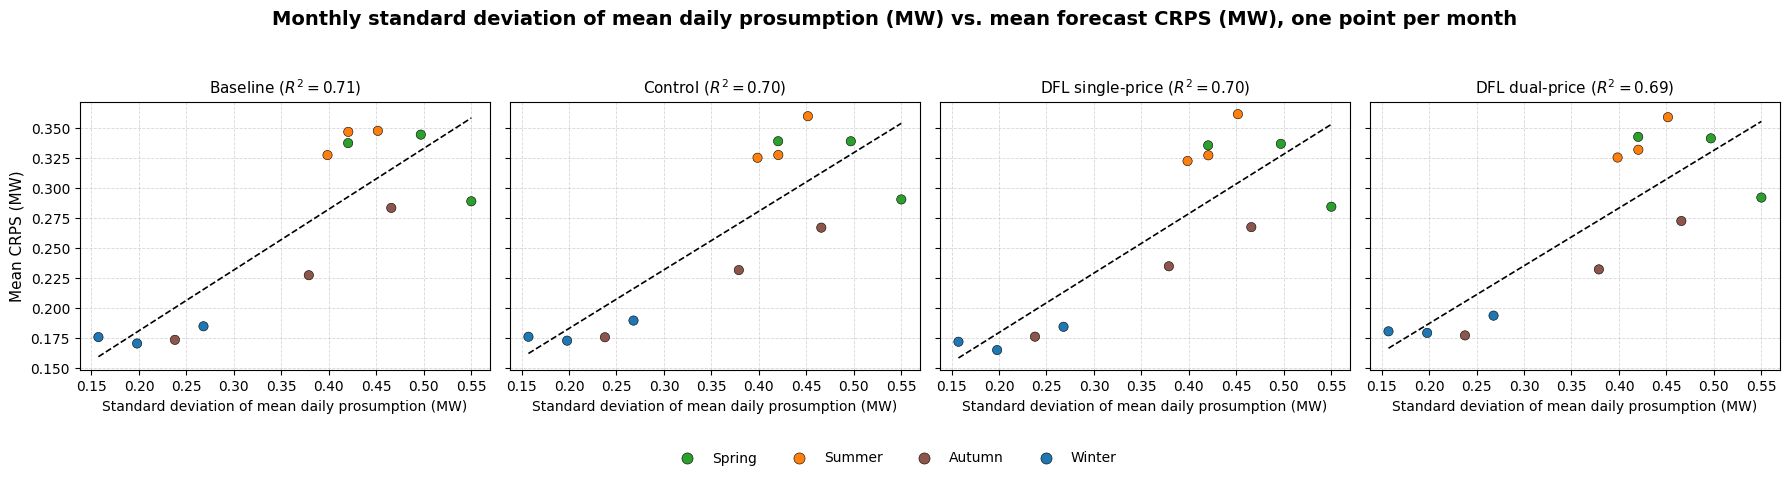

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from eval_raw import DATA_DIR, TEST_START, TEST_END

raw = pd.read_csv(DATA_DIR / "df_full.csv", parse_dates=["datetime"]).set_index("datetime")
if raw.index.tz is None:
    raw.index = raw.index.tz_localize("UTC")
test_raw = raw.loc[TEST_START:TEST_END, ["prosumption"]].copy()

daily_mean = test_raw.groupby(test_raw.index.date)["prosumption"].mean()
daily_mean.index = pd.to_datetime(daily_mean.index).to_period("M").astype(str)
day_to_day_std = daily_mean.groupby(level=0).std()
day_to_day_std.index.name = "month"
day_to_day_std.name = "prosumption_std"

crps_df["seed"] = crps_df["forecaster_id"].apply(seed_of)
per_seed_crps = crps_df.groupby(["family", "seed", "month"])["crps"].mean().reset_index()
crps_stats = per_seed_crps.groupby(["family", "month"])["crps"].mean().reset_index()
crps_stats = crps_stats.merge(day_to_day_std, on="month")

# Colour points by season instead of by forecaster -- forecaster is already given by
# each panel's own title, so season is the more informative encoding here. Same
# SEASON_COLORS convention used throughout this project's other seasonal figures.
SEASON_MONTHS = {"Winter": [12, 1, 2], "Spring": [3, 4, 5], "Summer": [6, 7, 8], "Autumn": [9, 10, 11]}
SEASON_ORDER = ["Spring", "Summer", "Autumn", "Winter"]
SEASON_COLORS = {"Spring": "C2", "Summer": "C1", "Autumn": "C5", "Winter": "C0"}


def month_to_season(month_str: str) -> str:
    month_num = int(month_str.split("-")[1])
    for season, months_in_season in SEASON_MONTHS.items():
        if month_num in months_in_season:
            return season
    raise ValueError(month_str)


crps_stats["season"] = crps_stats["month"].apply(month_to_season)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharex=True, sharey=True)
for ax, family in zip(axes, FAMILY_ORDER):
    fam = crps_stats[crps_stats["family"] == family].sort_values("month")
    x, y = fam["prosumption_std"].to_numpy(), fam["crps"].to_numpy()
    colors = [SEASON_COLORS[s] for s in fam["season"]]

    ax.scatter(x, y, color=colors, s=45, zorder=3, edgecolors="black", linewidths=0.4)

    slope, intercept = np.polyfit(x, y, 1)
    r2 = np.corrcoef(x, y)[0, 1] ** 2
    xs = np.linspace(x.min(), x.max(), 50)

    ax.plot(xs, slope * xs + intercept, "k--", linewidth=1.2)

    ax.set_title(f"{family} ($R^2={r2:.2f}$)", fontsize=11)
    ax.grid(linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Standard deviation of mean daily prosumption (MW)")

axes[0].set_ylabel("Mean CRPS (MW)", fontsize=11)

legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=SEASON_COLORS[s],
           markeredgecolor="black", markeredgewidth=0.4, markersize=8, label=s)
    for s in SEASON_ORDER
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05), fontsize=10, frameon=False)

fig.suptitle("Monthly standard deviation of mean daily prosumption (MW) vs. mean forecast CRPS (MW), one point per month", fontsize=14, fontweight="bold", y=0.99)

fig.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()